## Descriptive Statistics with Python:
1. Mean
2. Median
3. Mode
4. Variance and Standard Deviation
5. Normal Distribution and Empirical Rule
6. Quantiles
7. Box plots
8. Skewness and Kurtosis

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('index_1.csv')
data.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [112]:
data['month'] = pd.to_datetime(data['date'])
data['month'] = data['month'].dt.to_period('M')
data['month']

0       2024-03
1       2024-03
2       2024-03
3       2024-03
4       2024-03
         ...   
3631    2025-03
3632    2025-03
3633    2025-03
3634    2025-03
3635    2025-03
Name: month, Length: 3636, dtype: period[M]

#### 1. Mean

Arithmetic mean is a sum of a given set of numbers divided by the count of those numbers. It can be defined in the following formula:
$$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

where $\bar{x}$ is a symbol for the mean, $x_i$ is a numeric property we are interested in, $n$ is a count of the properties, $\sum_{i=1}^{n}$ is a summation symbol, with $i=1$ as a starting point, and $n$ being the number of summation sequences. In python we could just use .mean() function:

In [113]:
data['money'].mean()

31.74685918591859

Which gives us a mean price of the coffee saled from our dataset. But we can also build a function from scratch that does the same thing.

In [114]:
def count_mean(column):
    mean = (sum(column) / len(column))
    return mean

In [115]:
count_mean(data['money'])

31.74685918591859

Mean is used to measure the central tendency of the data. While using it we have to be aware of the fact that the mean is sensitive to the outliers, meaning that if we have extreme values in our set it will affect the mean significantly. Let's say we want to find the average income in a given area populated mostly by average middle class people - so far no problem, but let's assume that Bill Gates also happened to live in that area. Suddenly the average shifts to the right, and if the shift is drastic enough, the mean will be well above the majority of the population, therefore misleading.

#### 1.1 Trimmed Mean

Trimmed mean is a tool to combat this exact problem. Trimmed mean cuts off the certain number of values from both ends of the sorted dataset, and the mean is calculated from that subset of values. It can be described with the following formula:
$$\bar{x} = \frac{\sum_{i=1+p}^{n-p} x_i}{n-2p}$$

where $p$ is the number of values subtracted from both ends of the sorted dataset. We can use the following scipy function to get the trimmed mean:

In [116]:
from scipy import stats

stats.trim_mean(data['money'], 0.05)

31.920659743433106

where 0.05 is 5% of data removed from both ends of the dataset.

#### 1.2 Weighted mean
If we have different frequencies of values in our dataset, we might want to use weighted mean. Let's say we want to calculate the monthly average value of transactions. In some months there will be fewer transactions than in others, thus the average value from that month should matter less in the overall monthly average - weighted mean does exactly this.

In weighted mean, every value is multiplied by weight, then the product is summed and divided by total number of weights.
It can be defined like this:
$$\bar{x} = \frac{\sum_{i=1}^{n} x_i w_i}{\sum_{i=1}^{n} w_i}$$
where $w_i$ is a weight value and ${\sum_{i=1}^{n} w_i}$ is a sum of all weights.

So in this case we will need to get our monthly average and the weights - In this case the amount of transactions per month.

In [117]:
mean_grouped = pd.DataFrame(data.groupby('month')['money'].mean().round(2))
count_grouped = data.groupby('month')['money'].size().reset_index(name='amount_of_transactions')
count_and_mean = mean_grouped.merge(count_grouped, on='month', how='left') 
count_and_mean

,month,money,amount_of_transactions
0,2024-03,34.22,206
1,2024-04,34.29,196
2,2024-05,33.95,267
3,2024-06,34.18,227
4,2024-07,29.18,237
5,2024-08,27.99,272
6,2024-09,29.04,344
7,2024-10,32.61,426
8,2024-11,33.17,259
9,2024-12,31.81,259


The simplest way to calculate the weighted mean is to use numpys average function with weights, like so:

In [118]:
numpy_weighted_mean = np.average(count_and_mean['money'], weights=count_and_mean['amount_of_transactions'])
numpy_weighted_mean

31.74815731573157

But we can also build a function that does the same thing.

In [119]:
def weighted_mean(avg_value, weights):
    w_mean = (avg_value * weights).sum() / weights.sum()
    return w_mean

weighted_mean(count_and_mean['money'], count_and_mean['amount_of_transactions'])

31.74815731573157

In [120]:
my_weighted_mean = weighted_mean(count_and_mean['money'], count_and_mean['amount_of_transactions'])
numpy_weighted_mean == my_weighted_mean

True

#### 2. Median

Median is the middle value in a dataset. If we have a set of numbers: 1, 2, 3 - median is 2, but if there is even number of values we have to take the average of two middle values, like: 1, 2, 3, 4 - median is (2+3)/2 = 2.5
To get median we can just use .median() function:

In [121]:
data['money'].median()

32.82

or, like before, we can build it from scratch.

In [122]:
def find_median(values):
    sorted_values = values.sort_values()
    n = len(sorted_values)
    x = n // 2
    if n % 2 == 0:
        return (sorted_values.iloc[x-1] + sorted_values.iloc[x])/2
    else:
        return sorted_values.iloc[x]

find_median(data['money'])

32.82

Median, since it is that middle value, it is less affected by the outliers. If we have following set of numbers: [1,2,3,4,5] and [1,2,3,5,100], the median in both is 3. Comparing this to the mean informs us about the skewness of the data. The mean of the first set is 15/5 = 3, so the same as the median, and the mean of the second set is 111/5=22.2, which is much larger than the median suggesting that some extreme values pulled it in that direction.

#### 3. Mode

Mode is the most frequent value in the dataset, and there is a function for it too:

In [123]:
data['money'].mode()

0    35.76
Name: money, dtype: float64

but who needs that if you can build your own.

In [124]:
def find_mode(column):
    count = column.value_counts()
    return count.head(1)

find_mode(data['money'])

money
35.76    1014
Name: count, dtype: int64

Apart from numeric data, mode can be used for categorical data. For example, we can find the most popular coffee using the mode function.

In [125]:
find_mode(data['coffee_name'])

coffee_name
Americano with Milk    824
Name: count, dtype: int64

#### 4. Variance and Standard Deviation

Variance and Standard deviation allow us to determine how data varies, and how a value can deviate from the mean. Low standard deviation signals that the values are set tighter around the mean.
Variance is a mean of squared difference between random variable and the mean of population/sample, and standard deviation is a square root of variance.
Following formula is used to define those:

Variance:
$$Var(X) = E[(X - \mu)^2]$$

Standard Deviation:
$$\sigma = \sqrt{E[(X - \mu)^2]} $$

where $X$ is the random variable, $\mu$ is population/sample mean.
In Python you can get them by using the following numpy functions:

In [126]:
np.var(data['money']), np.std(data['money'])

(24.199012687541153, 4.919249199577223)

It is important to note that numpy variance uses the formula for the entirety of the population:

$$E = \frac{\sum_{i=1}^{n}(x_i - \mu)^2}{n}$$

but there is also pandas version, which uses slightly different formula for sample of the population, called Bessel's correction, where:
$$E = \frac{\sum_{i=1}^{n}(x_i - \mu)^2}{n - 1}$$
which will give us different numbers:

In [127]:
f"numpy variance for population: {np.var(data['money'])}, pandas variance for sample: {data['money'].var()}"

'numpy variance for population: 24.199012687541153, pandas variance for sample: 24.205669912489583'

For more in depth description you can see Allan B. Downey's blog: https://www.allendowney.com/blog/2024/06/08/which-standard-deviation/ 

So in order to get variance we need to: 
1. Get the mean value of the population/sample
2. Get the difference between a variable and the mean
3. Square the value of the difference
4. Repeat 2 and 3 for the whole population/sample
5. Add those squared differences
6. Divide it by $n$ (for population) or ${n-1}$ (for sample)

In [128]:
def find_population_variance(column):
   variance = ((column - column.mean())**2).sum()/len(column)
   return variance
def find_sample_variance(column):
   variance = ((column - column.mean())**2).sum()/(len(column)-1)
   return variance
find_population_variance(data['money']), find_sample_variance(data['money'])


(24.199012687542126, 24.205669912490556)

Now, to find standard deviation, we just have to take the square root of the variance.

In [129]:
def find_standard_deviation_pop(column):
    stand_dev = np.sqrt(find_population_variance(column))
    return stand_dev
def find_standard_deviation_samp(column):
    stand_dev = np.sqrt(find_sample_variance(column))
    return stand_dev
find_standard_deviation_pop(data["money"]), find_standard_deviation_samp(data["money"])

(4.919249199577322, 4.919925803555431)

#### 5. Empirical Rule and Normal Distribution

The empirical rule tells us about the character of the data, but only for the normal distribution. Normal distribution means that the data is distributed in a symmetric bell-shaped curve. Distribution is most often presented on a histogram, which is a chart visualizing the frequency of values in the dataset. If we check our column by plotting a histogram with seaborn library, we will see that it is not normally distributed:

<Axes: xlabel='money', ylabel='Count'>

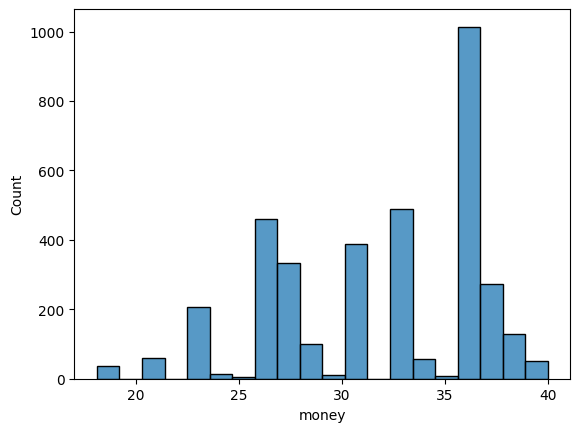

In [130]:
sns.histplot(data = data['money'], bins=20)

'bins=20' is used here to divide the data into a 20 equally spaced out bins of values, and then it checks how many values fall into those bins. We can increase the amount of bins to get more precise outcome. From this histogram we can see that the data is neither symmetrical nor bell-shaped. So, instead of that I will take a dataset that is normally distributed. One of the most common examples is weight and height, and if we think about it, it makes sense. Most people are of an average height, so they fall within the mean value range. But the further we move away from the average, the fewer people fall within these values, and there are only a few extreme values ​​at the ends of them. 
 
 For the following example I used 'Heights and Weights Dataset' from Kaggle (https://www.kaggle.com/datasets/burnoutminer/heights-and-weights-dataset).

In [ ]:
data02 = pd.read_csv('SOCR-HeightWeight.csv')
data02 = data02.sample(n=5000, random_state=42)
data02.head()

,Index,Height(Inches),Weight(Pounds)
6868,6869,68.42447,134.2855
24016,24017,67.89663,111.9666
9668,9669,67.65922,135.9871
13640,13641,69.01299,126.3802
14018,14019,69.01055,100.1810


<Axes: xlabel='Height(Inches)', ylabel='Count'>

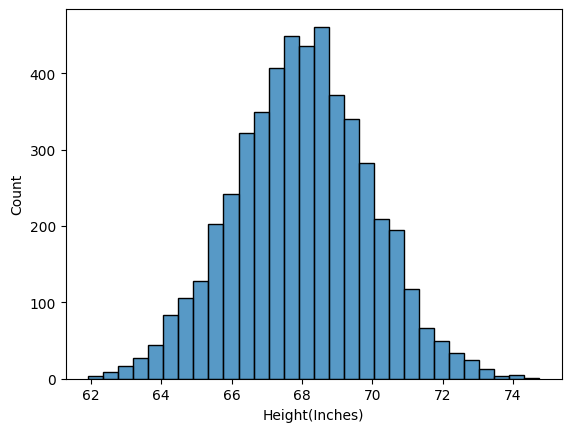

In [132]:
sns.histplot(data = data02['Height(Inches)'], bins=30)

From that the data looks normally distributed, but we cannot just eyeball it! For this purpose, there are special tools available in the Scipy library. Here I will use Shapiro-Wilk test. For that reason I selected a sample from the population (data02.sample(n=5000, random_state=42)) restricting the dataset to 5000 elements - it is because Shapiro-Wilk test works best with up to 5000 elements.

In [133]:
from scipy.stats import shapiro
stat, p_value = shapiro(data02['Height(Inches)'])
stat, p_value

(0.999597430229187, 0.40985050797462463)

The test gives us two values, where p value is a probability of a null hypothesis - here as: "Data is normally distributed". When the p value is bigger than 0.05, then we failed to reject the null hypothesis, meaning that the data is most likely normally distributed. The second value is the W-statistic which estimates how close the data is to normal distribution - closer to 1 means closer to normal distribution. In our case, the p value is much higher than 0.05 and W-statistic is very close to 1, meaning that our data is normally distributed. For the comparison we can also check our previous dataset:

In [134]:
stat, p_value = shapiro(data['money'])
stat, p_value

(0.9289262890815735, 1.6887613918157958e-38)

The p value here is extremely small: 1.69 × 10⁻³⁸, so that means that the data is not normally distributed.

Now we can move on to the empirical rule, sometimes called 68-95-99.7 rule, which refers to the percentages of values contained within the intervals from the mean. Approximately the 68% of values is contained within the interval of one standard deviation from the mean, 95% is within two standard deviations and 99.7% in three standard deviations from the mean - but only if we are dealing with the normal distribution.

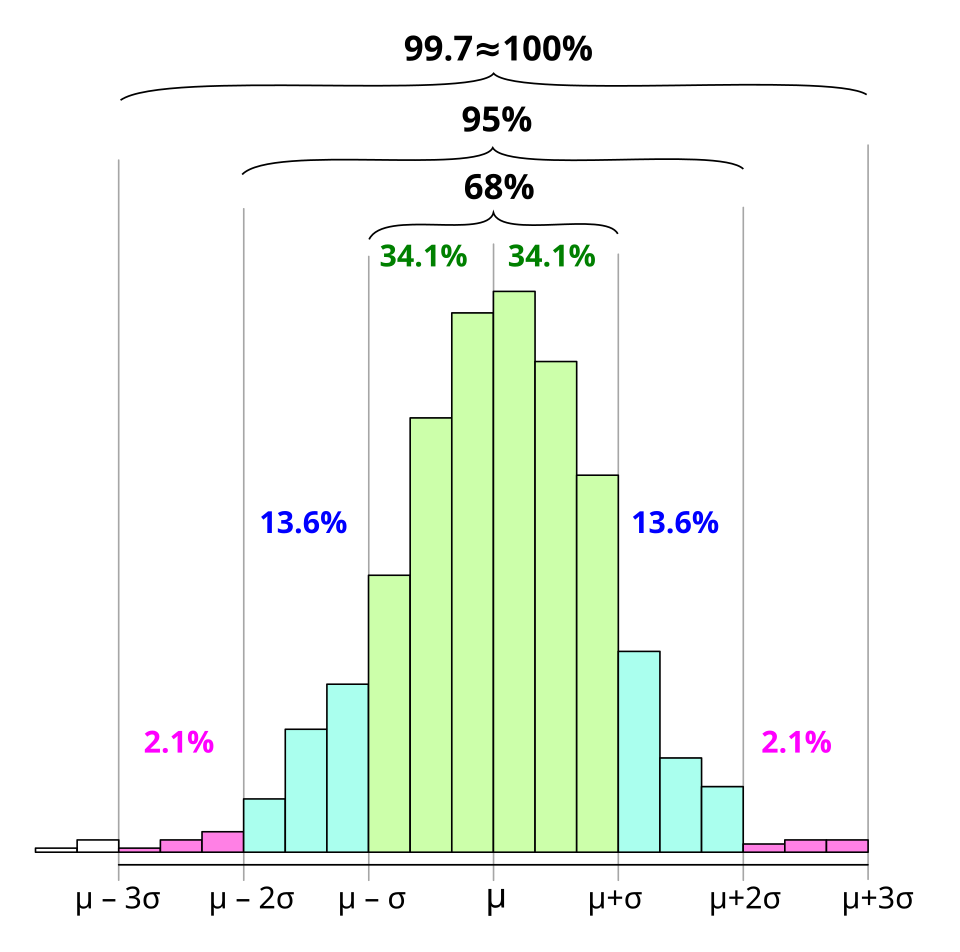 


Image by Melikamp, https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule#/media/File:Empirical_rule_histogram.svg, 
licensed under: CC BY-SA 4.0

Given that the data is normally distributed, we can for example say that we have 68% chance for the random variable to fall within the range between the mean &#177; standard deviation. Here we can also check if the empirical rule applies to our case.

In [135]:
data02mean = count_mean(data02['Height(Inches)'])
data02std = find_standard_deviation_samp(data02['Height(Inches)'])

sixty_eight = data02[(data02['Height(Inches)'] >= data02mean - data02std) & (data02['Height(Inches)'] <= data02mean + data02std)]
sixty_eight

,Index,Height(Inches),Weight(Pounds)
6868,6869,68.42447,134.2855
24016,24017,67.89663,111.9666
9668,9669,67.65922,135.9871
13640,13641,69.01299,126.3802
14018,14019,69.01055,100.1810
...,...,...,...
18389,18390,68.52986,130.1434
8670,8671,68.93627,138.0941
11839,11840,67.28489,105.2101
4013,4014,68.57098,141.1859


In [136]:
actual_percentage = (len(sixty_eight)/len(data02))*100
actual_percentage

68.42

#### 6. Quantiles

Quantiles are cut points that divide the values in the dataset into equal intervals, each containing the same perceny of data falling below that dividing point. There are three main cases of quantiles: quartiles - dividing data into 4 intervals, deciles - dividing data into 10 intervals, and percentiles - dividing data into 100 intervals. So for example if you take a test and your score is in 90th percentile, it means that your score is the same or better than 90% of all students. We can also check the 90th percentile of height in our Height and Weight dataset with the following function:

In [137]:
np.percentile(data02['Height(Inches)'], 90)

70.484209

Using cm it is:

In [138]:
data02['Height(cm)'] = data02['Height(Inches)']*2.54
np.percentile(data02['Height(cm)'], 90)

179.02989086000002

Meaning that, based on our data, if you are 179 cm tall, you are taller than 90% of the population.

Important notion that often apperas with quantiles is Inter Quartile Range (IQR), which is used for measuring dispersion of the data. IQR uses middle 50% of data: $IQR = Q3 - Q1$; we take the value at the 75th percentile and subtract the value at the 25th percentile The advantage of IQR is that it is less influenced by outliers, than mean or standard deviation.

In [139]:
IQR = np.percentile(data02['Height(cm)'], 75) - np.percentile(data02['Height(cm)'], 25)
IQR

6.538512450000013

#### 7. Box plots

One of the classic ways of visualizing the data distribution is a boxplot, which is based on quantiles. We can generate one using the seaborn library in the following way:

<Axes: ylabel='Height(cm)'>

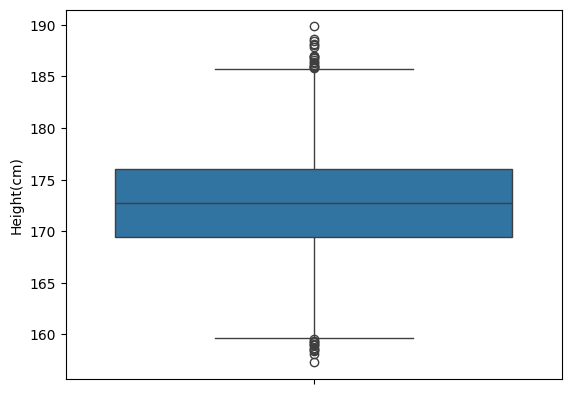

In [140]:
sns.boxplot(data02['Height(cm)'])

The boxplot is based around five values: minimum within lower bound, first quartile (or 25th percentile), median which is synonymous with the second quartile (or 50th percentile), third quartile (or 75th percentile) and maximum within upper bound. The box shows the first quartile as the bottom of the box to be around 170, the second quartile (or the median) as line in the middle of the box to be around 172.5, and third quartile as the top of the box to be around 175. The so-called whiskers show variability outside the quartiles. It is a convention to take lower bound to be $Q1 - 1.5 * IQR$, and upper bound as $Q3 +1.5 * IQR$, which are not real data points, but rather a construction of the bound for the minimum and maximum to be found.

#### 8. Skewness and Kurtosis
Skewness comes back to the issue of distribution, and it applies to the measure of asymmetry. Positive number signify right-skewness with longer tail on the right,  negative numbers signify left-skewness with longer tail on the left and closer to zero the output is the more symmetrical the data is. Using pandas function we get: 

In [141]:
data02['Height(cm)'].skew(), data['money'].skew()

(0.005559826735877194, -0.523253548313041)

From that we see that the height data is very symmetrical, and our previous dataset containing coffee prices is skewed to the left. We can also visualize those:

Text(0.5, 1.0, 'skewness = -0.523253548313041')

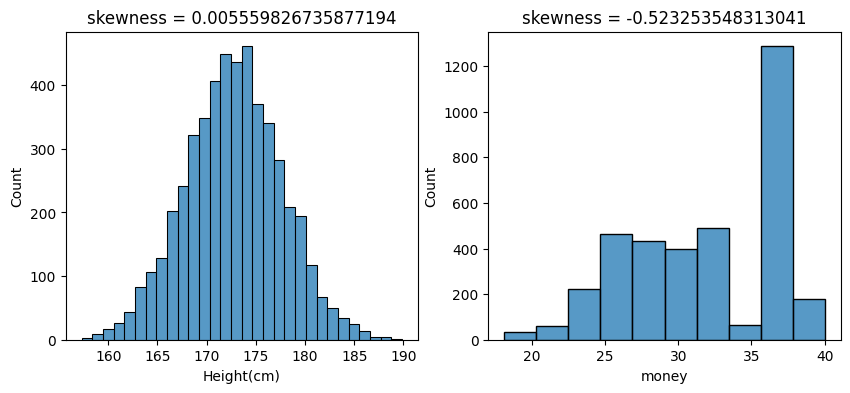

In [142]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(x= data02['Height(cm)'], bins=30, ax=axes[0])
axes[0].set_title(f"skewness = {data02['Height(cm)'].skew()}")

sns.histplot(x=  data['money'], bins=10, ax=axes[1])
axes[1].set_title(f"skewness = {data['money'].skew()}")


Skewness can say something interesting about the relationship of mean, mode and median. If skewness is 0, meaning that the data is symmetric, then the mean, median and mode are equal.

In [143]:
count_mean(data02['Height(cm)']), find_mode(data02['Height(cm)']), find_median(data02['Height(cm)'])

(172.730635107,
 Height(cm)
 173.881694    2
 Name: count, dtype: int64,
 172.73126489999999)

All those values are almost the same, since the data is almost symmetrical. But it is not the case for asymmetrical data. For right skewed data we have mode < median < mean, and for left skewed data mean < median < mode. We can check it with the coffee data set.

In [144]:
count_mean(data['money']), find_median(data['money']), find_mode(data['money']) 

(31.74685918591859,
 32.82,
 money
 35.76    1014
 Name: count, dtype: int64)

Kurtosis on the other hand describes tailedness of the data. If the output number is >0, called Leptokurtic, means that the data has more extreme outliers, <0, called Platykurtic, means that the data is more packed and there is less outliers. We check that with the following function:

In [145]:
data02['Height(cm)'].kurtosis(), data['money'].kurtosis()

(-0.05810581564902151, -0.6604012487590349)

Both datasets show slightly negative kurtosis — height's tails are close to normal (near 0), while coffee's more negative kurtosis (-0.66) suggests flatter, lighter tails than normal, consistent with values spread across multiple common price points rather than concentrated with rare extreme outliers.